# Social Media Dopamine dataset Analysis

source =  https://www.kaggle.com/datasets/manaswinsripatnala/social-media-dopamine-and-productivity-dataset/data

## Profiling Dataset


In [2]:
# IMPORTING Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('social_media_dopamine_productivity.csv')
df.head(3)

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
0,P0001,synthetic_ai,1,16,13-17,Female,South Asian,Indian,India,High school,...,Yes,9,2,3,Boredom,Critical,8.8,9.2,2.1,9.5
1,P0002,synthetic_ai,1,17,13-17,Male,East Asian,Chinese,China,High school,...,Yes,10,1,1,Curiosity,Critical,9.5,9.8,1.5,9.8
2,P0003,synthetic_ai,1,15,13-17,Female,Black/African,Nigerian,Nigeria,High school,...,Yes,8,2,5,Boredom,Severe,8.0,8.5,2.8,9.0


In [4]:
# Data size
df.shape

(300, 66)

In [5]:
# Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    300 non-null    object 
 1   data_source                       300 non-null    object 
 2   synthetic_flag                    300 non-null    int64  
 3   age                               300 non-null    int64  
 4   age_group                         300 non-null    object 
 5   gender                            300 non-null    object 
 6   race_ethnicity                    300 non-null    object 
 7   nationality                       300 non-null    object 
 8   country_of_residence              300 non-null    object 
 9   education_level                   300 non-null    object 
 10  employment_status                 300 non-null    object 
 11  occupation_category               300 non-null    object 
 12  relation

In [6]:
# Missing Value Check
df.isna().sum()

participant_id                  0
data_source                     0
synthetic_flag                  0
age                             0
age_group                       0
                               ..
productivity_decline_score      0
dopamine_dysregulation_index    0
digital_wellbeing_score         0
sm_addiction_risk_score         0
notes                           0
Length: 66, dtype: int64

In [7]:
# Duplicate Check
df.duplicated().sum()

np.int64(0)

In [8]:
# Basic statistic (only numerical columns)
df.describe()

,synthetic_flag,age,avg_daily_sm_hours,years_on_social_media,avg_daily_screen_time_hours,avg_sleep_hours,avg_work_study_hours_per_day,dopamine_rush_feel_score,reward_seeking_behavior,fomo_score,...,decision_fatigue_score,anxiety_when_phone_unavailable,restlessness_score,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
count,300.0,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1.0,36.310000,4.030000,7.503333,7.830000,7.325000,7.100000,4.920000,2.556667,4.590000,...,3.963333,4.300000,4.143333,4.283333,5.413333,28.740000,4.354333,4.853667,6.170333,5.006000
std,0.0,15.175029,2.034181,2.690872,2.271556,1.033005,2.673417,2.490168,1.308624,2.142553,...,2.414142,2.792129,2.610012,2.925449,2.575123,23.587999,2.750095,2.692319,2.649709,2.922093
min,1.0,15.000000,0.500000,3.000000,3.000000,4.500000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.500000,1.000000,1.100000,0.500000
25%,1.0,24.000000,2.500000,5.000000,6.375000,6.875000,6.000000,3.000000,1.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,10.000000,1.800000,2.400000,4.200000,2.200000
50%,1.0,33.500000,3.500000,8.000000,7.500000,7.500000,8.000000,4.000000,2.000000,4.000000,...,3.000000,3.000000,3.500000,3.000000,6.000000,24.000000,3.200000,3.800000,7.000000,4.000000
75%,1.0,46.250000,5.500000,10.000000,9.500000,8.000000,9.000000,7.000000,3.000000,6.000000,...,5.000000,7.000000,6.000000,7.000000,8.000000,48.000000,6.200000,6.800000,8.800000,7.200000
max,1.0,75.000000,9.000000,14.000000,13.000000,9.000000,9.500000,10.000000,5.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,90.000000,9.900000,10.000000,9.900000,10.000000


1. mean = rata-rata
2. median = nilai tengah (berguna jika ada outlier)
3. std - Standard Deviasi = Seberapa menyebar data dari rata-ratanya
    std Kecil (6.9
                7.0
                7.1
                7.0
                6.9)
    std Besar (3
                5
                7
                9
                11)

Notes: Outlier -> nilai yang jauh berbeda dari mayoritas data. (1,2,3,4,5,6,30) 30 adalah kandidat outlier, Outlier dapat memebgaruhi mean, std, coorelation, regression


In [9]:
# Data Categorical Check
df.columns

Index(['participant_id', 'data_source', 'synthetic_flag', 'age', 'age_group',
       'gender', 'race_ethnicity', 'nationality', 'country_of_residence',
       'education_level', 'employment_status', 'occupation_category',
       'relationship_status', 'avg_daily_sm_hours', 'years_on_social_media',
       'primary_platform', 'secondary_platform', 'daily_check_frequency',
       'first_check_of_day', 'late_night_scrolling', 'sm_during_work_study',
       'sm_during_meals', 'notifications_always_on', 'scroll_without_purpose',
       'doomscrolling_frequency', 'content_type_consumed',
       'avg_daily_screen_time_hours', 'avg_sleep_hours', 'sleep_quality',
       'exercise_frequency', 'avg_work_study_hours_per_day',
       'dopamine_rush_feel_score', 'reward_seeking_behavior', 'fomo_score',
       'comparison_to_others_score', 'validation_seeking_score',
       'boredom_to_phone_reflex', 'inability_to_delay_gratification',
       'attention_span_minutes', 'deep_work_duration_minutes',
   

CATEGORICAL COLUMNS = 
gender
primary_platform
education_level
employment_status
sleep_quality

In [10]:
df["gender"].value_counts()

gender
Female        148
Male          145
Non-binary      7
Name: count, dtype: int64

In [11]:
df["primary_platform"].value_counts()

primary_platform
Instagram        95
Facebook         89
YouTube          50
LinkedIn         26
TikTok           21
WeChat           12
Twitter/X         5
Douyin/TikTok     1
Reddit            1
Name: count, dtype: int64

In [12]:
df["education_level"].value_counts()

education_level
Undergraduate    151
Postgraduate     110
High school       39
Name: count, dtype: int64

In [13]:
df["employment_status"].value_counts()


employment_status
Full-time employed    188
Student                72
Retired                27
Part-time employed      6
Job seeker              3
Self-employed           2
Freelancer              2
Name: count, dtype: int64

In [14]:
df["sleep_quality"].value_counts()

sleep_quality
Good         146
Fair          75
Poor          43
Very good     26
Very poor     10
Name: count, dtype: int64

In [15]:
#Column Check
df.columns.tolist()

['participant_id',
 'data_source',
 'synthetic_flag',
 'age',
 'age_group',
 'gender',
 'race_ethnicity',
 'nationality',
 'country_of_residence',
 'education_level',
 'employment_status',
 'occupation_category',
 'relationship_status',
 'avg_daily_sm_hours',
 'years_on_social_media',
 'primary_platform',
 'secondary_platform',
 'daily_check_frequency',
 'first_check_of_day',
 'late_night_scrolling',
 'sm_during_work_study',
 'sm_during_meals',
 'notifications_always_on',
 'scroll_without_purpose',
 'doomscrolling_frequency',
 'content_type_consumed',
 'avg_daily_screen_time_hours',
 'avg_sleep_hours',
 'sleep_quality',
 'exercise_frequency',
 'avg_work_study_hours_per_day',
 'dopamine_rush_feel_score',
 'reward_seeking_behavior',
 'fomo_score',
 'comparison_to_others_score',
 'validation_seeking_score',
 'boredom_to_phone_reflex',
 'inability_to_delay_gratification',
 'attention_span_minutes',
 'deep_work_duration_minutes',
 'task_switching_frequency',
 'difficulty_starting_tasks',
 '

### Summary Dataset

In [16]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100
})

summary

,dtype,unique,missing,missing_%
participant_id,object,300,0,0.0
data_source,object,1,0,0.0
synthetic_flag,int64,1,0,0.0
age,int64,61,0,0.0
age_group,object,7,0,0.0
...,...,...,...,...
productivity_decline_score,object,5,0,0.0
dopamine_dysregulation_index,float64,37,0,0.0
digital_wellbeing_score,float64,47,0,0.0
sm_addiction_risk_score,float64,46,0,0.0


Unique =  Cardinality = jumlah nilai unik dalam sebuah kolom. (Male,Female,Male,Female) -> Cardinality = 2

## DATA CLEANING & DATA QUALITY

In [17]:
pd.set_option("display.max_info_columns", 100)

In [18]:
# Missing Value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    300 non-null    object 
 1   data_source                       300 non-null    object 
 2   synthetic_flag                    300 non-null    int64  
 3   age                               300 non-null    int64  
 4   age_group                         300 non-null    object 
 5   gender                            300 non-null    object 
 6   race_ethnicity                    300 non-null    object 
 7   nationality                       300 non-null    object 
 8   country_of_residence              300 non-null    object 
 9   education_level                   300 non-null    object 
 10  employment_status                 300 non-null    object 
 11  occupation_category               300 non-null    object 
 12  relation

ada dua kolom yang memiliki null


In [19]:
df["secondary_platform"].isna().sum()

np.int64(3)

In [20]:
# Missing Value Columns Check (cari kolom mana yang ada null nya)

missing = df.isna().sum()
missing[missing > 0]

secondary_platform     3
severity_stage        89
dtype: int64

In [21]:
# Drop missing values
dfc = df.dropna()

In [22]:
print("Original dataset:", df.shape)
print("clean dataset:", dfc.shape)

Original dataset: (300, 66)
clean dataset: (211, 66)


In [23]:
# Duplicated values that is should not (Identifier Columns) -> participant_id customer_id employee_id transaction_id
df.duplicated().sum()
df["participant_id"].duplicated().sum()

np.int64(0)

No duplicated entries based on Participant_id

In [24]:
# Data Type 
df["productivity_decline_score"].value_counts()

productivity_decline_score
None/Minimal    154
Early            53
Critical         35
Moderate         29
Severe           29
Name: count, dtype: int64

walaupun nama kolim nya score, tapi value nya bukanlah Float64 atau int (bukan numeric) tapi categorical/ordinal variable.

##### Jenis Categorical
1. Nominal -> Kategori TANPA URUTAN
2. Ordinal -> Kategori DENGAN URUTAN

productivity_decline_score adalah Ordinal (ada urutan atau level di kategori nya),
lalu kolom tersebut merupakan kolom semantik (memiliki makna yang sesuai nama kolom dan value nya)

In [25]:
df['severity_stage'].value_counts(dropna=False)

severity_stage
Boredom                  126
NaN                       89
Comparison                27
FOMO                      26
Validation seeking        15
Low motivation             4
Overwhelm                  3
Perfectionism              3
Curiosity                  1
Peer pressure              1
Boredom/Depression         1
Dopamine rush              1
Gaming/SM combined         1
Comparison/Validation      1
Boredom/Anxiety            1
Name: count, dtype: int64

##### Range (nilai secara angka tidak mungkin? )

Contoh:
1. age = -5
2. sleep = 40 hours
3. screen_time = -2 hours

In [26]:
df['age'].describe()

count    300.000000
mean      36.310000
std       15.175029
min       15.000000
25%       24.000000
50%       33.500000
75%       46.250000
max       75.000000
Name: age, dtype: float64

In [27]:
df['avg_daily_sm_hours'].describe()

count    300.000000
mean       4.030000
std        2.034181
min        0.500000
25%        2.500000
50%        3.500000
75%        5.500000
max        9.000000
Name: avg_daily_sm_hours, dtype: float64

In [28]:
df['avg_sleep_hours'].describe()

count    300.000000
mean       7.325000
std        1.033005
min        4.500000
25%        6.875000
50%        7.500000
75%        8.000000
max        9.000000
Name: avg_sleep_hours, dtype: float64

In [29]:
##### Numerical Columns check
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
synthetic_flag,300.0,1.000000,0.000000,1.0,1.000,1.0,1.00,1.0
age,300.0,36.310000,15.175029,15.0,24.000,33.5,46.25,75.0
avg_daily_sm_hours,300.0,4.030000,2.034181,0.5,2.500,3.5,5.50,9.0
years_on_social_media,300.0,7.503333,2.690872,3.0,5.000,8.0,10.00,14.0
avg_daily_screen_time_hours,300.0,7.830000,2.271556,3.0,6.375,7.5,9.50,13.0
avg_sleep_hours,300.0,7.325000,1.033005,4.5,6.875,7.5,8.00,9.0
avg_work_study_hours_per_day,300.0,7.100000,2.673417,0.0,6.000,8.0,9.00,9.5
dopamine_rush_feel_score,300.0,4.920000,2.490168,1.0,3.000,4.0,7.00,10.0
reward_seeking_behavior,300.0,2.556667,1.308624,1.0,1.000,2.0,3.00,5.0
fomo_score,300.0,4.590000,2.142553,1.0,3.000,4.0,6.00,10.0


## EDA - Exploratory Data Analysis

In [30]:
# Outlier
dfc['avg_daily_screen_time_hours'].describe()

count    211.000000
mean       8.943128
std        1.652296
min        6.000000
25%        7.500000
50%        8.500000
75%       10.000000
max       13.000000
Name: avg_daily_screen_time_hours, dtype: float64

- Q1 (25%) = 7.5
- Q2 (50%) = 8.5
- Q3 (75%) = 10

In [31]:
#IQR 
Q1 = dfc["avg_daily_screen_time_hours"].quantile(0.25)
Q3 = dfc["avg_daily_screen_time_hours"].quantile(0.75)

IQR = Q3-Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 7.5
Q3: 10.0
IQR: 2.5


IQR —> Interquartile Range
IQR = 10.0 − 7.5
    = 2.5 jam

IQR untuk mengetahui penyebaran 50%  data tengah. Semakin besar IQR maka semakin tersebar bagian tengah data

In [32]:
# Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound)

Lower Bound:  3.75
Upper Bound:  13.75


Kenapa 1.5?

1.5 × IQR adalah aturan Tukey yang umum digunakan untuk mendeteksi potential outliers pada boxplot.

In [33]:
outliers = dfc[
    (dfc["avg_daily_screen_time_hours"] < lower_bound) |
    (dfc["avg_daily_screen_time_hours"] > upper_bound)
]

outliers

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes


In [34]:
#Potential Outliers
len(outliers)

0

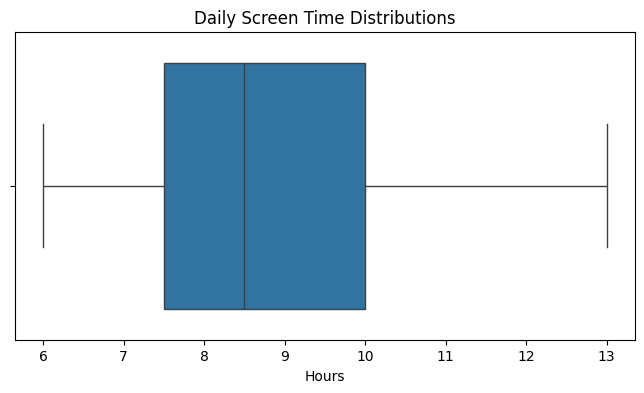

In [35]:
# Visualisasi Outliers

plt.figure(figsize=(8,4))

sns.boxplot(
    x=dfc['avg_daily_screen_time_hours']
)

plt.title('Daily Screen Time Distributions')
plt.xlabel('Hours')
plt.show()


tidak ada outlier

##### Univariate Distribution

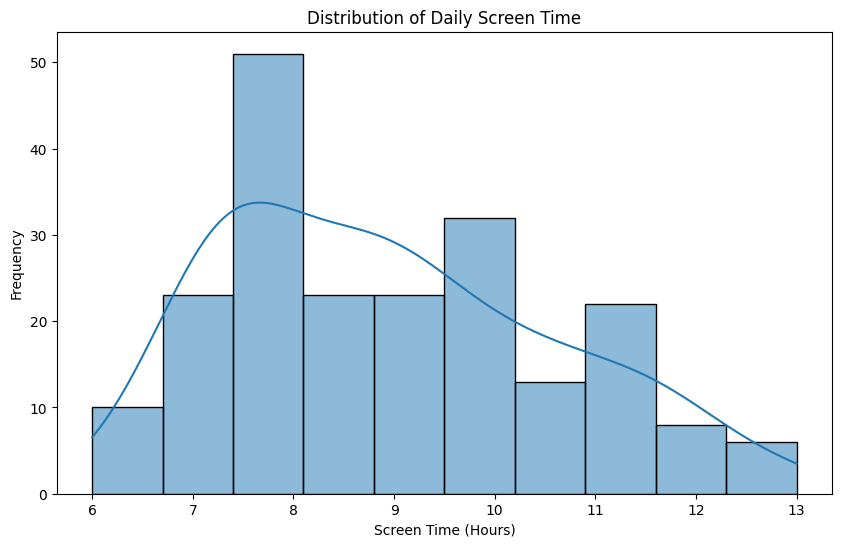

In [36]:
plt.figure(figsize=(10,6))

# histogram untuk melihat distribusi frekuensi 
sns.histplot(
    dfc["avg_daily_screen_time_hours"],
    bins = 10, # rentang nilai
    kde=True # kernel Density Estimate untuk melihat distribusi secara lebih halus
)

plt.title("Distribution of Daily Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Frequency")
plt.show()


Skewness = Kemiringan Distribusi
- '=0' -> Relatif Simetris
- '>0' -> Right Skewed / positive skew (Mean > Median)
- '<0' -> Left Skewed /  negative ske

Insight: Distribusi screen time harian miring, right skewed, dengan data paling banyak berkumpul di 8 jam dengan 50 frekuensi observasi

Skewness by numeric

In [37]:
skewness = dfc['avg_daily_screen_time_hours'].skew()
print("Skewness:", skewness)

Skewness: 0.4919539425162774


###### Dispersion

In [38]:
mean_screen_time = dfc["avg_daily_screen_time_hours"].mean()
median_screen_time = dfc["avg_daily_screen_time_hours"].median()

print("Mean:", mean_screen_time)
print("Median:", median_screen_time)

Mean: 8.943127962085308
Median: 8.5


Central Tendency -> nilai yang mewakili pusat data (8.5)

In [39]:
min_screen_time = dfc["avg_daily_screen_time_hours"].min()
max_screen_time = dfc["avg_daily_screen_time_hours"].max()

range_screen_time = max_screen_time - min_screen_time

print("Minimum:", min_screen_time)
print("Maximum:", max_screen_time)
print("Range:", range_screen_time)

Minimum: 6.0
Maximum: 13.0
Range: 7.0


Range -> melihat dua nilai esktrem max dan min

In [40]:
std_screen_time = dfc['avg_daily_screen_time_hours'].std()
print('Standard Deviation:', std_screen_time)

Standard Deviation: 1.6522964330274852


Standard deviation (SD) -> mengukur seberapa jauh data cenderung menyebar dari mean.

SD memberi tahu seberapa tersebar data di sekitar pusat tersebut

IQR -> mengukur sebaran 50% data yang berada di tengah.

In [41]:
# Statistical Summary
dfc[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
synthetic_flag,211.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
age,211.0,29.232227,9.801754,15.0,21.00,27.0,36.00,55.0
avg_daily_sm_hours,211.0,4.985782,1.637299,2.5,3.50,5.0,6.00,9.0
years_on_social_media,211.0,6.691943,2.379452,3.0,5.00,6.0,9.00,13.0
avg_daily_screen_time_hours,211.0,8.943128,1.652296,6.0,7.50,8.5,10.00,13.0
avg_sleep_hours,211.0,6.881517,0.893196,4.5,6.25,7.0,7.50,8.0
avg_work_study_hours_per_day,211.0,7.414692,1.529028,0.0,6.00,8.0,8.50,9.5
dopamine_rush_feel_score,211.0,6.080569,2.016161,2.0,4.00,6.0,8.00,10.0
reward_seeking_behavior,211.0,3.142180,1.103532,1.0,2.00,3.0,4.00,5.0
fomo_score,211.0,5.611374,1.673509,2.0,4.00,5.0,7.00,10.0


##### Univariative Categorical

gender
primary_platform
secondary_platform
severity_stage
productivity_decline_score

In [42]:
dfc['gender'].value_counts()

gender
Female        110
Male           94
Non-binary      7
Name: count, dtype: int64

In [43]:
dfc['gender'].value_counts(normalize=True) *100

gender
Female        52.132701
Male          44.549763
Non-binary     3.317536
Name: proportion, dtype: float64

Female merupakan kategori dengan jumlah observasi terbesar (52.13%), diikuti Male (44.55%) dan Non-binary (3.32%).

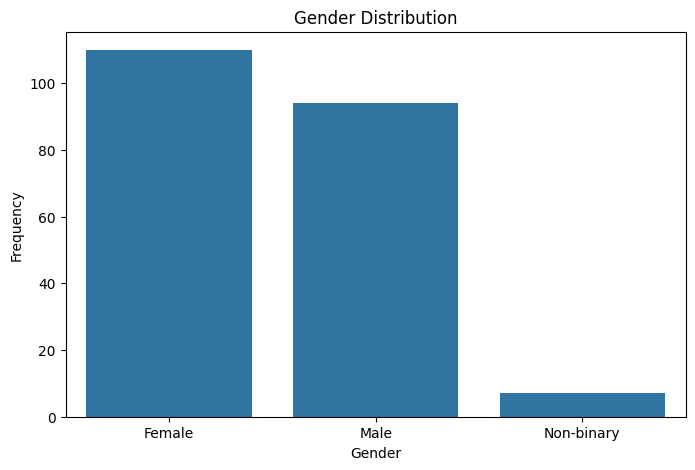

In [44]:
gender_count = dfc['gender'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=gender_count.index,
    y=gender_count.values
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()

In [45]:
dfc["primary_platform"].value_counts()

primary_platform
Instagram        88
Facebook         46
YouTube          41
TikTok           21
WeChat            5
LinkedIn          5
Twitter/X         3
Douyin/TikTok     1
Reddit            1
Name: count, dtype: int64

In [46]:
dfc["primary_platform"].value_counts(normalize=True) * 100

primary_platform
Instagram        41.706161
Facebook         21.800948
YouTube          19.431280
TikTok            9.952607
WeChat            2.369668
LinkedIn          2.369668
Twitter/X         1.421801
Douyin/TikTok     0.473934
Reddit            0.473934
Name: proportion, dtype: float64

Instagram merupakan primary platform yang paling banyak digunakan dalam dataset, dengan 88 observasi (41.71%), diikuti Facebook dengan 46 (21.80%) dan YouTube dengan 41 (19.43%)

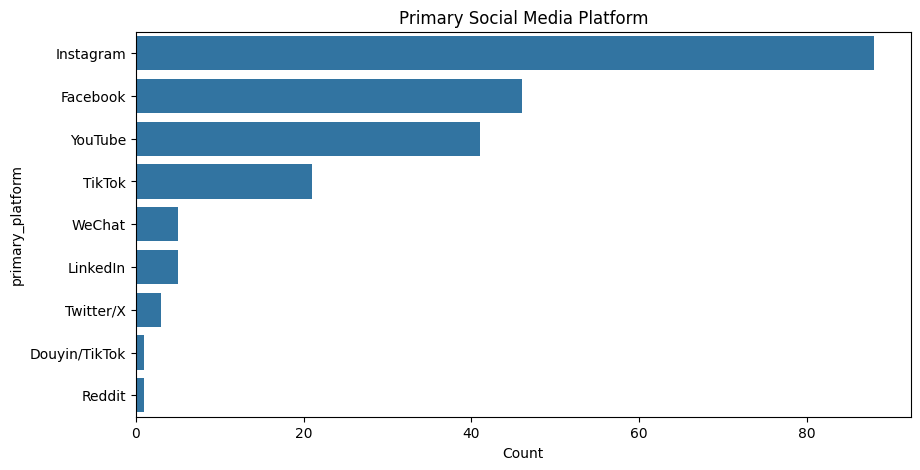

In [47]:
platform_counts = dfc['primary_platform'].value_counts()
plt.figure(figsize=(10,5))

sns.barplot(
    x=platform_counts.values,
    y=platform_counts.index
)

plt.title('Primary Social Media Platform')
plt.xlabel('Count')
plt.show()

In [48]:
dfc['severity_stage'].value_counts()

severity_stage
Boredom                  126
Comparison                27
FOMO                      26
Validation seeking        15
Low motivation             4
Overwhelm                  3
Perfectionism              3
Curiosity                  1
Peer pressure              1
Boredom/Depression         1
Dopamine rush              1
Gaming/SM combined         1
Comparison/Validation      1
Boredom/Anxiety            1
Name: count, dtype: int64

In [49]:
dfc['severity_stage'].value_counts(normalize=True)*100

severity_stage
Boredom                  59.715640
Comparison               12.796209
FOMO                     12.322275
Validation seeking        7.109005
Low motivation            1.895735
Overwhelm                 1.421801
Perfectionism             1.421801
Curiosity                 0.473934
Peer pressure             0.473934
Boredom/Depression        0.473934
Dopamine rush             0.473934
Gaming/SM combined        0.473934
Comparison/Validation     0.473934
Boredom/Anxiety           0.473934
Name: proportion, dtype: float64

Nominal categorical = kategori yang tidak memiliki urutan alami

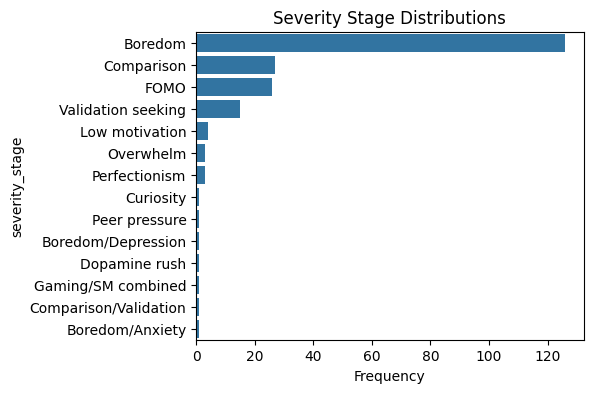

In [50]:
stage_counts = dfc['severity_stage'].value_counts()

plt.figure(figsize=(5,4))

sns.barplot(
    x=stage_counts.values,
    y=stage_counts.index,
  
)

plt.title('Severity Stage Distributions')
plt.xlabel('Frequency')
plt.show()

severity_stage:
- Categorical nominal
- Boredom dominan (59.72%)
- Banyak kategori minor
- Ada beberapa kategori gabungan
- Tidak ada ordinal ordering yang jelas

In [51]:
dfc.columns.tolist()

['participant_id',
 'data_source',
 'synthetic_flag',
 'age',
 'age_group',
 'gender',
 'race_ethnicity',
 'nationality',
 'country_of_residence',
 'education_level',
 'employment_status',
 'occupation_category',
 'relationship_status',
 'avg_daily_sm_hours',
 'years_on_social_media',
 'primary_platform',
 'secondary_platform',
 'daily_check_frequency',
 'first_check_of_day',
 'late_night_scrolling',
 'sm_during_work_study',
 'sm_during_meals',
 'notifications_always_on',
 'scroll_without_purpose',
 'doomscrolling_frequency',
 'content_type_consumed',
 'avg_daily_screen_time_hours',
 'avg_sleep_hours',
 'sleep_quality',
 'exercise_frequency',
 'avg_work_study_hours_per_day',
 'dopamine_rush_feel_score',
 'reward_seeking_behavior',
 'fomo_score',
 'comparison_to_others_score',
 'validation_seeking_score',
 'boredom_to_phone_reflex',
 'inability_to_delay_gratification',
 'attention_span_minutes',
 'deep_work_duration_minutes',
 'task_switching_frequency',
 'difficulty_starting_tasks',
 '

In [52]:

dfc['productivity_decline_score'].value_counts()

productivity_decline_score
None/Minimal    65
Early           53
Critical        35
Moderate        29
Severe          29
Name: count, dtype: int64

In [53]:
dfc['productivity_decline_score'].value_counts(normalize=True)*100

productivity_decline_score
None/Minimal    30.805687
Early           25.118483
Critical        16.587678
Moderate        13.744076
Severe          13.744076
Name: proportion, dtype: float64

In [54]:
severity_order = [
    'None/Minimal',
    'Early',
    'Moderate',
    'Severe',
    'Critical'

]

decline_counts = dfc['productivity_decline_score'].value_counts()
decline_counts = decline_counts.reindex(severity_order)
print(decline_counts)

productivity_decline_score
None/Minimal    65
Early           53
Moderate        29
Severe          29
Critical        35
Name: count, dtype: int64


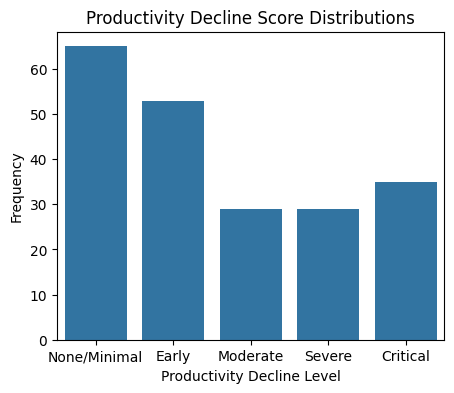

In [55]:
plt.figure(figsize=(5,4))

sns.barplot(
    x=decline_counts.index,
    y=decline_counts.values
)

plt.title("Productivity Decline Score Distributions")
plt.ylabel('Frequency')
plt.xlabel('Productivity Decline Level')
plt.show()

In [56]:
skewness = dfc['avg_daily_screen_time_hours'].skew()
print("Skewness:", skewness)

Skewness: 0.4919539425162774


## Bivariate Analysis (X <-> Y)

coorelation

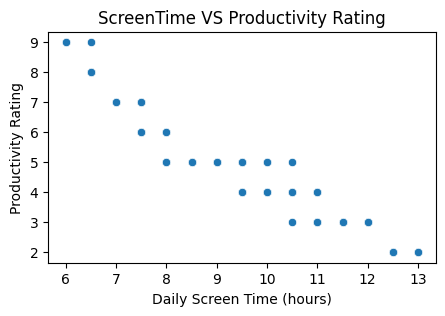

In [57]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=dfc,
    x= 'avg_daily_screen_time_hours',
    y= 'productivity_self_rating'
)

plt.title('ScreenTime VS Productivity Rating')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Productivity Rating')

plt.show()

Productivity turun -> Negative Relationship

Tidak terlihat outlier,

 Daily screen time punya hubungan negatif dengan productivity rating di dataset ini (belum tentu productivity turun karena screen time, mungkin ada faktor lain)

In [58]:
coorelation = dfc['avg_daily_screen_time_hours'].corr(
    dfc['productivity_self_rating']
)

print('Pearson Coorelation: ', coorelation)

Pearson Coorelation:  -0.9486638083728463


Hubungan linear negatif yang kuat antara daily screen dan productivity rating

Coefficient of determination R^2

In [59]:
r = coorelation 
r_squared = r **2

print("R^2:", r_squared)

R^2: 0.8999630213164723


R^2 menunjukan seberapa besar variasi pada variable Y yang dapat dijelaskan oleh hubungan linear dengan vatiable X dalam model linear sederhana

x= 'average_daily_screen_time_hours'

y= 'productivity_self_rating'

R^2= 0.90

sekitar 90% variasi productivity rating berkaitan dengan variasi screen time



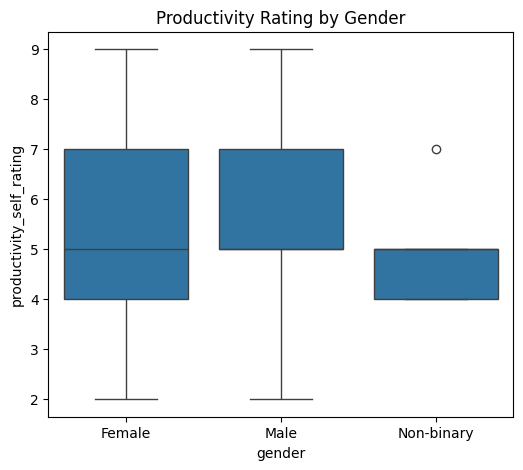

In [60]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=dfc,
    x="gender",
    y="productivity_self_rating"
)

plt.title('Productivity Rating by Gender')


plt.show()

boxplot menunjukan perbedaan distribusi laki dan perempuan memiliki distribusi yang lebih lebar

In [61]:
dfc.groupby('gender')['productivity_self_rating'].agg(
    ['count','mean','median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
gender,,,,,,
Female,110,5.063636,5.0,1.682491,2,9
Male,94,5.393617,5.0,1.392901,2,9
Non-binary,7,4.857143,5.0,1.069045,4,7


In [62]:
crosstab = pd.crosstab(
    dfc['primary_platform'],
    dfc['productivity_decline_score']
)

crosstab


productivity_decline_score,Critical,Early,Moderate,None/Minimal,Severe
primary_platform,,,,,
Douyin/TikTok,1,0,0,0,0
Facebook,2,9,3,32,0
Instagram,17,26,15,20,10
LinkedIn,0,0,0,5,0
Reddit,0,1,0,0,0
TikTok,10,1,2,0,8
Twitter/X,0,2,0,1,0
WeChat,0,3,0,1,1
YouTube,5,11,9,6,10


Crosstab untuk melihat jumlah observasi (count) pada kombinasi dua variabel kategorikal

In [63]:
# Dalam bentuk Persentase
crosstab_persen = pd.crosstab(
    dfc['primary_platform'],
    dfc['productivity_decline_score'],
    normalize='index'
) *100

crosstab_persen.round(2)


productivity_decline_score,Critical,Early,Moderate,None/Minimal,Severe
primary_platform,,,,,
Douyin/TikTok,100.00,0.00,0.00,0.00,0.00
Facebook,4.35,19.57,6.52,69.57,0.00
Instagram,19.32,29.55,17.05,22.73,11.36
LinkedIn,0.00,0.00,0.00,100.00,0.00
Reddit,0.00,100.00,0.00,0.00,0.00
TikTok,47.62,4.76,9.52,0.00,38.10
Twitter/X,0.00,66.67,0.00,33.33,0.00
WeChat,0.00,60.00,0.00,20.00,20.00
YouTube,12.20,26.83,21.95,14.63,24.39


<Figure size 1200x600 with 0 Axes>

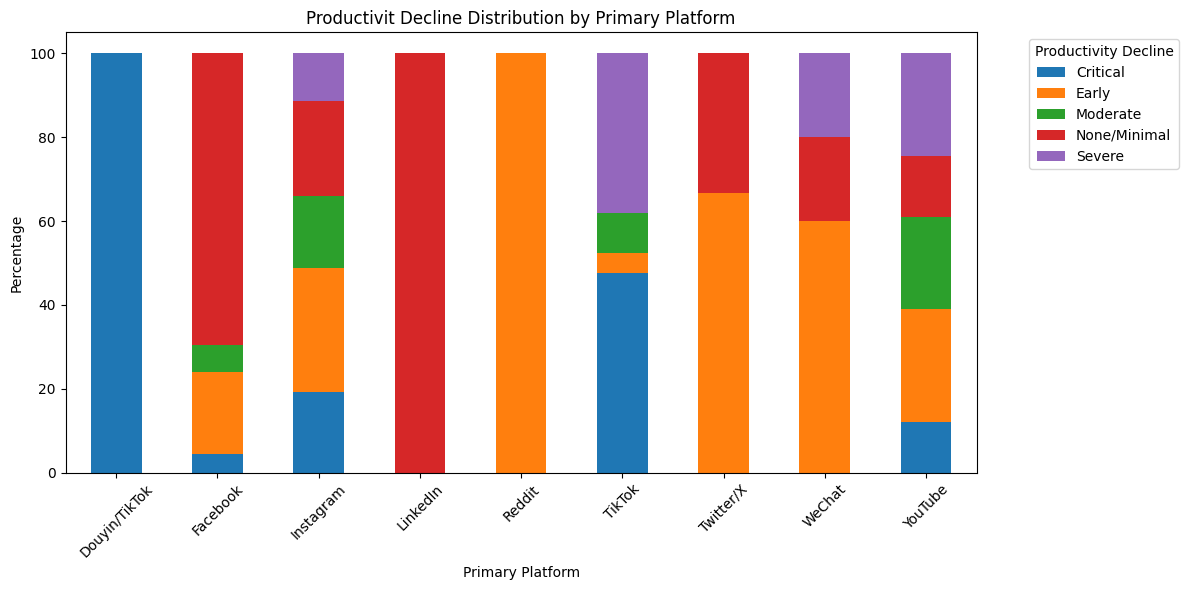

In [64]:
plt.figure(figsize=(12,6))

crosstab_persen.plot(
    kind = 'bar',
    stacked= True,
    figsize=(12,6)
)

plt.ylabel("Percentage"),
plt.xticks(rotation=45),
plt.xlabel('Primary Platform')
plt.title('Productivit Decline Distribution by Primary Platform')
plt.legend(
    title= 'Productivity Decline',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


## Multivariate Analysis (X <-> Y <-> Z)

apakah hubungan screen_time dengan productivity juga terlihat ketika mempertimbangkan sleep?

Numerical:
avg_daily_screen_time_hours
productivity_self_rating
avg_sleep_hours

In [66]:
dfc.columns.tolist()

['participant_id',
 'data_source',
 'synthetic_flag',
 'age',
 'age_group',
 'gender',
 'race_ethnicity',
 'nationality',
 'country_of_residence',
 'education_level',
 'employment_status',
 'occupation_category',
 'relationship_status',
 'avg_daily_sm_hours',
 'years_on_social_media',
 'primary_platform',
 'secondary_platform',
 'daily_check_frequency',
 'first_check_of_day',
 'late_night_scrolling',
 'sm_during_work_study',
 'sm_during_meals',
 'notifications_always_on',
 'scroll_without_purpose',
 'doomscrolling_frequency',
 'content_type_consumed',
 'avg_daily_screen_time_hours',
 'avg_sleep_hours',
 'sleep_quality',
 'exercise_frequency',
 'avg_work_study_hours_per_day',
 'dopamine_rush_feel_score',
 'reward_seeking_behavior',
 'fomo_score',
 'comparison_to_others_score',
 'validation_seeking_score',
 'boredom_to_phone_reflex',
 'inability_to_delay_gratification',
 'attention_span_minutes',
 'deep_work_duration_minutes',
 'task_switching_frequency',
 'difficulty_starting_tasks',
 '

In [68]:
# Correlation Matrix
multi_cols = [
    "avg_daily_screen_time_hours",
    "avg_daily_sm_hours",
    "avg_sleep_hours",
    "avg_work_study_hours_per_day",
    "fomo_score",
    "productivity_self_rating",
    "tasks_completed_per_day"
]

corr_matrix = dfc[multi_cols].corr()

corr_matrix.round(2)

,avg_daily_screen_time_hours,avg_daily_sm_hours,avg_sleep_hours,avg_work_study_hours_per_day,fomo_score,productivity_self_rating,tasks_completed_per_day
avg_daily_screen_time_hours,1.00,0.99,-0.97,-0.77,0.97,-0.95,-0.95
avg_daily_sm_hours,0.99,1.00,-0.97,-0.77,0.96,-0.95,-0.95
avg_sleep_hours,-0.97,-0.97,1.00,0.77,-0.94,0.91,0.92
avg_work_study_hours_per_day,-0.77,-0.77,0.77,1.00,-0.75,0.75,0.77
fomo_score,0.97,0.96,-0.94,-0.75,1.00,-0.94,-0.95
productivity_self_rating,-0.95,-0.95,0.91,0.75,-0.94,1.00,0.95
tasks_completed_per_day,-0.95,-0.95,0.92,0.77,-0.95,0.95,1.00


Variable tersebut dipilih karena ingin melihat hubungan antara:

Social media behavior
- screen time
- social media hours
- FOMO

Daily routine
- sleep
- work/study hours

Productivity
- productivity rating
- tasks completed

Screen Time ↔ SM Hours = 0.99

Screen Time ↔ Sleep     = -0.97

Screen Time ↔ FOMO      = 0.97

Ada hubungan yang kuat antar variable diatas,

Multicollinearity = beberapa predictor/feature memiliki hubungan linear yang sangat kuat satu sama lain

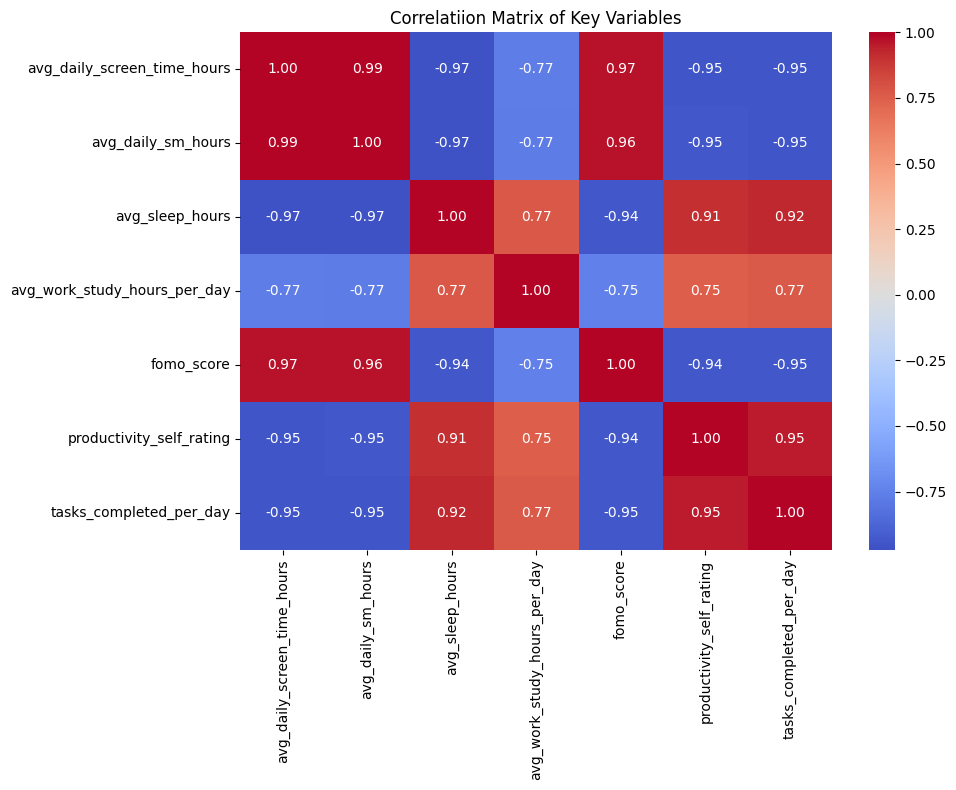

In [69]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap= 'coolwarm',
    fmt='.2f',
    center=0
)

plt.title('Correlatiion Matrix of Key Variables')
plt.tight_layout()
plt.show()

Sreen Time yang tinggi sangat berkesinambungan dengan waktu bersosial media dan pengaruh FOMO atau 'fear of missing out'. beberapa korelasi mencapai kurang lebih 0.95 hingga 0.99 (sangat tinggi hampir mencapai angka 1.00), ada kemungkinan redudancy atau feature dependence.

Correlation does not establish causation

## EDA Review & Insight Extraction

### Review
- mengecek apakah variabel yang digunakan memang masuk akal secara semantik;
- memilih temuan yang benar-benar penting;
- mengidentifikasi hubungan yang perlu diberi catatan;
- menyusun final insights yang nantinya bisa dipakai untuk portfolio Data Analyst.

In [70]:
# Review synthetic_flag
df["synthetic_flag"].value_counts()

synthetic_flag
1    300
Name: count, dtype: int64

In [71]:
df["synthetic_flag"].describe()

count    300.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: synthetic_flag, dtype: float64

"synthetic_flag" TIDAK memiliki informasi pembeda tiap observasi, atau disebut

CONSTANT VARIABLE. 

Constant Variable ini tidak berguna untuk EDA dan membandingkan observasi, jadi akan di exclude

In [73]:
# Review detox_relapse_reason
detox_type = df['detox_relapse_reason'].dtypes
detox_describe = df['detox_relapse_reason'].describe()

print(detox_type)
print(detox_describe)

int64
count    300.000000
mean      28.740000
std       23.587999
min        1.000000
25%       10.000000
50%       24.000000
75%       48.000000
max       90.000000
Name: detox_relapse_reason, dtype: float64


Secara Semantic kolom 'detox_relapse_reason' terdengar seperti seseorang mengalami relapse, namun value nya berupa 1,2,3, .. 90 (int64). Bukankah seharusnya berupa Kategori (object)?

Maka dari itu kolom 'detox_relapse_reason' akan di exclude

In [74]:
# Review notes
notes_type = df['notes'].dtypes
notes_describe = df['notes'].describe()

print(notes_type)
print(notes_describe)

float64
count    300.000000
mean       5.006000
std        2.922093
min        0.500000
25%        2.200000
50%        4.000000
75%        7.200000
max       10.000000
Name: notes, dtype: float64


Pada sumber kaggle author, tidak dijelaskan apa makna dari angka tersebut.

notes akan di exclude

In [75]:
# Review severity_stage
severity_stage_type = df['severity_stage'].dtypes
severity_stage_describe = df['severity_stage'].describe()

print(severity_stage_type)
print(severity_stage_describe)

object
count         211
unique         14
top       Boredom
freq          126
Name: severity_stage, dtype: object


In [77]:
df['severity_stage']

0         Boredom
1       Curiosity
2         Boredom
3         Boredom
4            FOMO
          ...    
295    Comparison
296          FOMO
297          FOMO
298       Boredom
299       Boredom
Name: severity_stage, Length: 300, dtype: object

In [79]:
df['severity_stage'].value_counts()

severity_stage
Boredom                  126
Comparison                27
FOMO                      26
Validation seeking        15
Low motivation             4
Overwhelm                  3
Perfectionism              3
Curiosity                  1
Peer pressure              1
Boredom/Depression         1
Dopamine rush              1
Gaming/SM combined         1
Comparison/Validation      1
Boredom/Anxiety            1
Name: count, dtype: int64

severity_stage tidak memiliki urutan alami masuk ke Categorical - Nominal

walaupun kolomnya bernama 'severity_stage', nilainya merepresantasikan perbedaan kondisi seperti Boredom, FOMO, dll. kolom ini tidak memiliki Order atau urutan untuk masuk kategori Ordinal sehingga menjadi Nominal

In [80]:
# Review productivity_decline_score
productivity_decline_score_type = df['productivity_decline_score'].dtypes
productivity_decline_score_describe = df['productivity_decline_score'].describe()

print(productivity_decline_score_type)
print(severity_stage_describe)

object
count         211
unique         14
top       Boredom
freq          126
Name: severity_stage, dtype: object


In [81]:
df['productivity_decline_score'].value_counts()


productivity_decline_score
None/Minimal    154
Early            53
Critical         35
Moderate         29
Severe           29
Name: count, dtype: int64

'productivity_decline_score' memiliki urutan, masuk ke kategori Ordinal

### Insight Extraction
Finding → Evidence → Interpretation → Limitation

#### Insight 1 - Screen Time vs Productivity
Pearson r = -0.9487
R² ≈ 0.90

terdapat hubungan negatif yang sangat kuat antara:
- avg_daily_screen_time_hours
- productivity_self_rating

Dalam dataset ini, responden dengan screen time harian yang lebih tinggi cenderung memiliki productivity rating yang lebih rendah

#### Insight 2 — Screen Time memiliki banyak hubungan kuat
Dari correlation matrix, pola yang muncul cukup konsisten:
- SM hours	+0.99
- FOMO	+0.97
- Sleep	-0.97
- Productivity	-0.95
- Tasks completed	-0.95
- Work/study hours	-0.77

Dalam dataset, screen time memiliki hubungan positif yang kuat dengan social-media usage dan FOMO, serta hubungan negatif yang kuat dengan sleep, productivity, tasks completed, dan work/study hours.

### Insight 3 — Productivity dan Tasks Completed
Correlation matrix menunjukkan:

productivity_self_rating
<->
tasks_completed_per_day


r ≈ +0.95

Responden dengan productivity rating yang lebih tinggi cenderung memiliki jumlah task yang diselesaikan per hari lebih tinggi.

### Insight 4 — Platform dan Productivity Decline
Distribusi kategori productivity decline berbeda antar-primary platform dalam dataset, tetapi kelompok dengan jumlah observasi kecil perlu diinterpretasikan secara hati-hat

Ada perbedaan distribusi antar-platform

- Instagram → 88
- Facebook  → 46
- YouTube   → 41
- TikTok    → 21
- WeChat    → 5
- Reddit    → 1


### Insight 5 — Gender
Dari boxplot dan group statistics:
- Female      → median 5
- Male        → median 5
- Non-binary  → median 5

Median productivity rating ketiga kelompok sama
Jadi gender bukan insight utama dari dataset ini

## EDA Summary

Dataset ini mengandung 300 baris observasi dan 66 kolom yang megandung penggunaan media sosial, indikator kebiasaan, waktu tidur, dan pola kerja atau belajar. Setelah menghapus missing values tersisa 211 baris observasi untuk proses EDA

### Data Quality Summary

- Tidak ada baris duplikasi yang terdeteksi
- Missing values ditemukkan pada kolom `secondary_platform` dan
  `severity_stage`.
- Proses Cleaning menghasilkan 211 baris tersisa dan disimpan di variabel dfc.
- `synthetic_flag` bersifat constant dan di-exclude.
- `detox_relapse_reason` dan `notes` juga di-exclude karena tidak ada makna semantic antara nama kolom dan nilainya
- `severity_stage` dianggap kategori Nominal.
- `productivity_decline_score` diangga kategori Ordinal.

### Key Findings
1. Daily screen time menunjukan hubungan correlation negatif yang sangat kuat dengan productivity  self ratin (r = -0.95). 

2. Daily screen time Berhubungan kuat dengan beberapa variable seperti social media hours (r = 0.99), FOMO score (r = 0.97),
   sleep hours (r = -0.97), dan tasks completed per day (r = -0.95).

3. Productivity self-rating sangat berhubungan kuat dengan tasks completed per day (r ≈ 0.95).

4. Distribusi productivity decline berbeda setiap platform media sosial, walaupun ada beberapa media sosial yang memiliki nilai sample yang kecil harus lebih diperhatikan intepretasinya

### Limitations
- Dataset synthetic tidak menunjukan populasi di dunia sesungguhnya (`synthetic_flag = 1` for all observations)
- proses Cleaning mengurangi jumlah baris dari 300 menjadi 211
- Beberapa variabel menunjukan korelasi yang sangat kuat bisajadi dipengaruhi oleh redundansi atau pengulangan bahkan hubungan terstruktur antar variabel nya
- Beberapa perhitungan dibuat berdasarkan metode 'self-reported' yang memungkinkan data ini bersifat subjektif
- Analisis yang dilakukan berdasarkan sebab belum tentu menyebabkan akibat 
- Beberapa kelompok kategori memiliki nilai sample yang sangat kecill

# CONCLUSION


Analisis data eksploratif (EDA) menunjukkan adanya hubungan yang kuat antara penggunaan media sosial, durasi penggunaan layar (*screen time*), indikator perilaku, dan produktivitas yang dilaporkan sendiri dalam kumpulan data ini. Secara khusus, durasi penggunaan layar harian yang lebih tinggi sangat berkaitan dengan peringkat produktivitas yang lebih rendah dan jumlah tugas yang diselesaikan lebih sedikit, serta memiliki hubungan positif dengan penggunaan media sosial dan FOMO

Temuan-temuan ini menggambarkan pola dalam kumpulan data yang dianalisis dan tidak boleh ditafsirkan sebagai hubungan sebab-akibat ataupun digeneralisasikan ke populasi yang lebih luas